In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('Mall_Customers.csv')

In [3]:
# 1. Extract Annual Income (Index 3) and Spending Score (Index 4)
X = df.iloc[:, [3, 4]].values

# 2. Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully! First 3 rows:")
print(X_scaled[:3])

Data scaled successfully! First 3 rows:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]]


c:\Users\HAMAIS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HAMAIS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HAMAIS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HAMAIS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

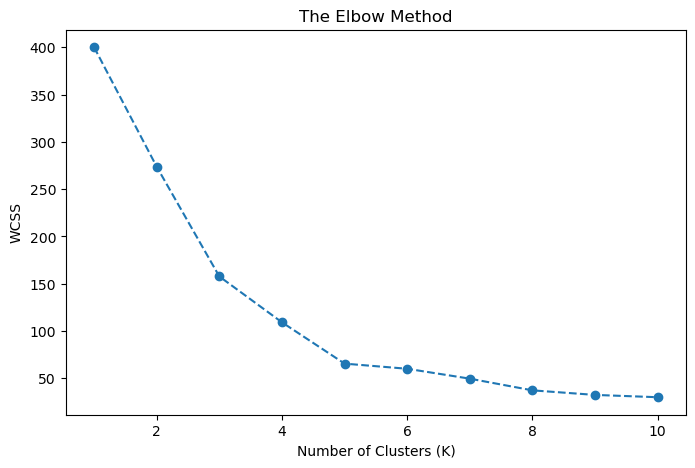

In [4]:
wcss = [] 

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [5]:
# 1. Apply K-Means with our chosen 5 clusters
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add the cluster labels to our original dataframe to see who belongs where
df['Cluster'] = cluster_labels

# 2. Apply PCA to reduce dimensions to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("K-Means and PCA completed successfully!")

K-Means and PCA completed successfully!


c:\Users\HAMAIS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


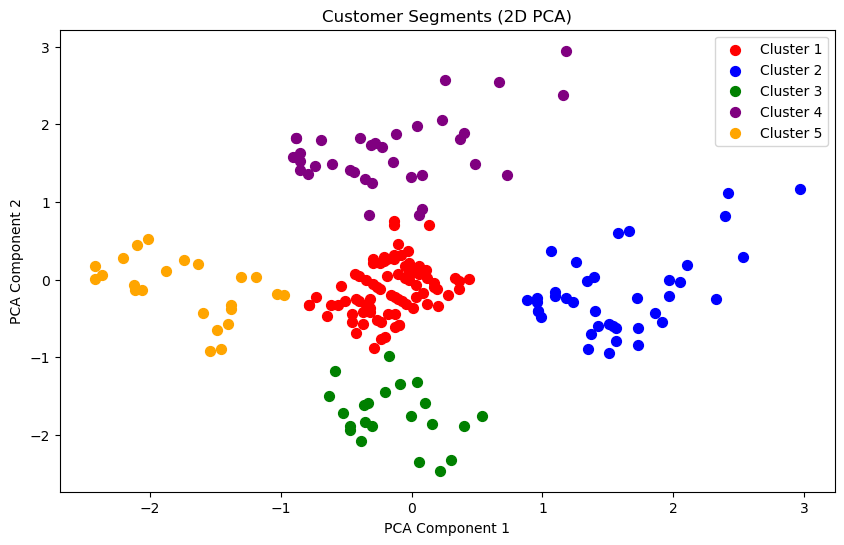

In [6]:
plt.figure(figsize=(10, 6))

# Define colors and labels for our 5 clusters
colors = ['red', 'blue', 'green', 'purple', 'orange']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

# Plot each cluster using the 2D PCA data
for i in range(5):
    plt.scatter(X_pca[cluster_labels == i, 0], X_pca[cluster_labels == i, 1], 
                s=50, c=colors[i], label=labels[i])

plt.title('Customer Segments (2D PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

In [7]:
# Group the data by our clusters and calculate the average income and spending
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

print(cluster_summary.round(2))

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                     55.30                   49.52
1                     86.54                   82.13
2                     25.73                   79.36
3                     88.20                   17.11
4                     26.30                   20.91


In [8]:
# Calculate the percentage of Men and Women within each cluster
gender_percent = pd.crosstab(df['Cluster'], df['Gender'], normalize='index') * 100

print(gender_percent.round(2))

Gender   Female   Male
Cluster               
0         59.26  40.74
1         53.85  46.15
2         59.09  40.91
3         45.71  54.29
4         60.87  39.13


**Business Insights & Interpretation**

* **Cluster 0 (Income: $55k, Spending: 50 | 59% Female, 41% Male):** 
*Standard Shoppers* : These customers represent the average, everyday middle-class buyer.

* **Cluster 1 (Income: $87k, Spending: 82 | 54% Female, 46% Male):** 
*Target VIPs* : High income and high spending. These are the most valuable loyal customers.

* **Cluster 2 (Income: $26k, Spending: 79 | 59% Female, 41% Male):** 
*Impulsive Buyers* : Low income but high spending. They are likely spending beyond their means or buying luxury items infrequently.

* **Cluster 3 (Income: $88k, Spending: 17 | 46% Female, 54% Male):** 
*Careful Spenders* : High income but low spending. A prime target demographic for marketing campaigns, and notably the only male-majority segment.

* **Cluster 4 (Income: $26k, Spending: 21 | 61% Female, 39% Male):** 
*Budget-Conscious* : Low income and low spending. They are likely strictly buying essential items, containing the highest female majority.